## 8. Stakeholder Report

### Purpose

Translate the work from Notebooks 01–06 into a concise stakeholder-facing
report for the Data Science Academy Student Success Office.

The report answers the six business questions through the evidence already
established in the project and connects the findings to practical advising
actions.

**Important:** this notebook does not retrain or redesign the model. It
summarizes the validated modeling and interpretability results.


## 1. Executive Summary

### Business problem

The Student Success Office wants to identify students who are likely to fail
or withdraw **early enough for advisors to act**, while also understanding
why a student was flagged.

### What we built

- Cleaned and validated the OULAD data.
- Created an early-risk feature table using information available through **day 28**.
- Compared a simple **Logistic Regression baseline** with a **Random Forest ensemble** using student-level grouped cross-validation.
- Selected Random Forest based on the strongest mean Average Precision.
- Added global and individual model interpretation.
- Evaluated how predictive performance changes at **days 7, 14, 21, and 28**.
- Identified the strongest early assessment checkpoint.
- Converted the findings into an advisor workflow.

### Main result

The Random Forest achieved:

- **AP = 0.8716**
- **ROC AUC = 0.8358**
- **Precision = 0.8005**
- **Recall = 0.7108**
- **F1 = 0.7529**
- **Accuracy = 0.7538**

The Logistic Regression baseline achieved:

- **AP = 0.8512**
- **ROC AUC = 0.8179**
- **Precision = 0.7634**
- **Recall = 0.7243**
- **F1 = 0.7433**
- **Accuracy = 0.7358**

The Random Forest therefore provides stronger overall ranking and classification performance,
while Logistic Regression has slightly higher recall at the default threshold.


## 2. Data and Early-Warning Design

The project combines student information, registration, assessment, and
course-website activity.

The final modeling unit is one **student-course record**.

### Early prediction cutoff

Features from assessments and VLE activity were restricted to information
available on or before **day 28**.

This makes the prediction a genuine early-warning setup rather than a model
that uses information from the end of the course.

### Target

`is_at_risk = 1` when the final outcome is **Fail or Withdrawn**.

The target in the final feature table is:

- Not At Risk: **15,385 (47.2%)**
- At Risk: **17,208 (52.8%)**

So the modeling target is relatively balanced in this dataset; nevertheless,
risk-focused metrics such as Average Precision, recall, precision, and F1
remain useful for evaluating an early-warning system.


## 3. Model Comparison

### Validation design

A **5-fold StratifiedGroupKFold** was used with `id_student` as the grouping
variable.

This is important because a student can appear in multiple course records.
The validation check showed **zero student overlap in every fold**.

### Results

| Model | AP | ROC AUC | Precision | Recall | F1 | Accuracy |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | **0.8716** | **0.8358** | **0.8005** | 0.7108 | **0.7529** | **0.7538** |
| Logistic Regression | 0.8512 | 0.8179 | 0.7634 | **0.7243** | 0.7433 | 0.7358 |

### Interpretation

Random Forest improves Average Precision by about **0.0205** over the baseline
and also improves ROC AUC, precision, F1, and accuracy.

The trade-off is slightly lower recall than Logistic Regression. This matters
because an advising team may prefer to catch more at-risk students even if
that creates additional alerts.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

comparison = pd.read_csv(PROCESSED_DIR / "model_comparison.csv")
oof = pd.read_csv(PROCESSED_DIR / "oof_predictions.csv")

print(comparison.round(4))


                 Model      AP  AP std  ROC AUC  Precision  Recall      F1  \
0        Random Forest  0.8716  0.0085   0.8358     0.8005  0.7108  0.7529   
1  Logistic Regression  0.8512  0.0114   0.8179     0.7634  0.7243  0.7433   

   Accuracy  
0    0.7538  
1    0.7358  


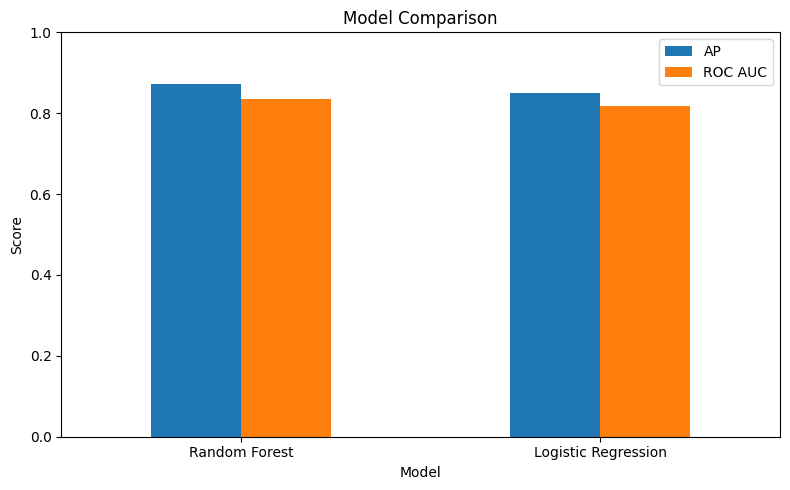

In [3]:
# Visual comparison of AP and ROC AUC.
plot_df = comparison.set_index("Model")[["AP", "ROC AUC"]]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Operating Threshold

At the default threshold of **0.50**, the selected Random Forest produced:

- **TP = 12,232**
- **FN = 4,976**
- **FP = 3,048**
- **TN = 12,337**

Threshold choice should ultimately reflect advising capacity and the relative
cost of missing an at-risk student versus sending an additional alert.

The tested threshold trade-off was:

| Threshold | Flagged | Precision | Recall | F1 |
|---:|---:|---:|---:|---:|
| 0.30 | 24,388 | 0.6419 | **0.9098** | 0.7527 |
| 0.40 | 19,473 | 0.7211 | 0.8160 | **0.7656** |
| 0.50 | 15,280 | 0.8005 | 0.7108 | 0.7530 |
| 0.60 | 12,018 | 0.8663 | 0.6050 | 0.7124 |
| 0.70 | 9,479 | **0.9224** | 0.5081 | 0.6552 |

### Stakeholder interpretation

A threshold around **0.40** gives the highest tested F1 and catches more
at-risk students than 0.50, while 0.30 prioritizes recall.

There is no universally correct threshold: the Student Success Office should
choose it together with the number of advisors and the capacity for
follow-up.


In [4]:
thresholds = np.arange(0.30, 0.71, 0.10)
y = oof["actual"].astype(int)
p = oof["predicted_probability"]

rows = []
from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    pred = (p >= t).astype(int)
    rows.append({
        "threshold": round(float(t), 2),
        "flagged": int(pred.sum()),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
    })

threshold_table = pd.DataFrame(rows)
threshold_table.round(4)


,threshold,flagged,precision,recall,f1
0,0.3,24388,0.6419,0.9098,0.7527
1,0.4,19473,0.7211,0.8160,0.7656
2,0.5,15280,0.8005,0.7108,0.7530
3,0.6,12018,0.8663,0.6050,0.7124
4,0.7,9479,0.9224,0.5081,0.6552


## 5. Early-Warning Timing and Assessment Checkpoints

### How early can risk be flagged?

The same Random Forest approach was evaluated using progressively larger
early-data windows:

| Cutoff | Average Precision | ROC AUC |
|---:|---:|---:|
| Day 7 | **0.8027** | **0.7730** |
| Day 14 | **0.8208** | **0.7876** |
| Day 21 | **0.8540** | **0.8183** |
| Day 28 | **0.8716** | **0.8358** |

### Insight

A meaningful early-risk signal is already present by **day 7**. Performance
improves as more evidence becomes available, with **day 28 producing the
strongest performance among the tested cutoffs**.

This supports an operational approach of **early screening followed by
progressive updating**, rather than waiting until day 28 for the first alert.

### Strongest early assessment checkpoint

Among assessments scheduled by day 28 and submitted by day 28, the strongest
single assessment-level risk signal was:

- **CCC / 2014B / CMA**
- Assessment day: **18**
- Students with scores: **1,346**
- Not At Risk mean score: **74.45**
- At Risk mean score: **47.49**
- Risk-signal ROC AUC: **0.7901**

Other strong checkpoints included CCC / 2014J / CMA (day 18, AUC 0.7614),
DDD / 2013B / TMA (day 25, AUC 0.7532), DDD / 2013B / CMA (day 23, AUC 0.7518),
and DDD / 2013J / TMA (day 25, AUC 0.7502).

### Insight

The strongest checkpoint provides a concrete academic point at which advisors
can pay particular attention to performance. Assessment **performance**, not
simply the number of assessments taken, is the stronger signal identified in
the feature-level EDA.

The assessment analysis excludes assessments with missing dates and uses only
scores available by the stated early cutoff, so the checkpoint results remain
consistent with the early-warning framing.


## 6. Global Interpretation

Permutation importance on a deterministic 1,000-row sample showed the
following strongest individual features:

| Feature | Importance |
|---|---:|
| `code_module` | **0.0811** |
| `active_days` | **0.0494** |
| `highest_education` | **0.0434** |
| `total_clicks` | **0.0356** |
| `avg_clicks_per_active_day` | **0.0258** |
| `early_max_score` | **0.0250** |
| `active_sites` | **0.0243** |
| `early_mean_score` | **0.0216** |

When grouped into broader themes:

| Feature group | Importance |
|---|---:|
| **Engagement** | **0.1407** |
| Background | 0.1027 |
| Course context | 0.0998 |
| Early academic performance | 0.0811 |
| Registration / study load | 0.0457 |

### Interpretation

**Engagement is the largest feature group.** Course context and background
variables also carry substantial predictive information, while early academic
performance remains an important signal.

These are predictive associations in the fitted model, not proof that changing
one feature will cause an outcome to change.


## 7. Business Questions - Answers

### Q1. Which combination of factors predicts risk?

The model uses a combination of **course context, engagement, background,
early academic performance, and registration/study-load information**.
Engagement is the strongest grouped signal.

### Q2. How early can we flag risk?

A meaningful signal is present by **day 7** (AP 0.8027, ROC AUC 0.7730).
Performance improves through day 28, where the tested model reaches **AP 0.8716**
and **ROC AUC 0.8358**. This supports early screening with repeated updates.

### Q3. Which student groups face higher risk?

EDA showed meaningful differences across education, age, socioeconomic
background, and course module.

Examples:

- No Formal Qualifications: **70.32%** at risk
- Lower Than A Level: **61.15%**
- A Level or Equivalent: **47.97%**
- HE Qualification: **43.83%**
- Post Graduate Qualification: **34.50%**

For IMD, the observed at-risk rate ranged from **64.84%** in the 0–10%
band to **42.47%** in the 90–100% band.

These patterns should guide support and investigation, **not deterministic or
punitive decisions**.

### Q4. How does website activity relate to outcome?

At-risk students had lower early engagement in the EDA:

- Median total clicks: **141 vs 292**
- Median active days: **9 vs 16**
- Median active sites: **19 vs 27**
- Median clicks per active day: **15.31 vs 19.08**

Most importantly, among students with no early VLE activity, **95.71% were
at risk**, compared with **47.13%** among students with some early VLE
activity.

### Q5. Which early assessments are strongest?

The strongest single early assessment checkpoint was **CCC / 2014B / CMA on
day 18**, with **1,346** students with scores and a risk-signal ROC AUC of
**0.7901**. Mean score was **74.45** for Not At Risk students versus
**47.49** for At Risk students.

In the broader EDA, early assessment performance also separated the groups:
Not At Risk mean early score **76.96** versus **65.95** for At Risk. The number
of assessments taken was almost identical, suggesting that **performance**
carried the stronger early signal than simply the assessment count.

### Q6. How should an advisor use a flagged prediction?

Use the risk score together with its explanation:

**Risk score → explanation → advisor verification → targeted support**

The model should prioritize students and suggest what to investigate; the
advisor remains responsible for confirming the student's actual situation.


## 8. Individual Example

A high-risk example selected without using the final target:

- Student: **614471**
- Module: **DDD**
- Presentation: **2014J**
- Predicted at-risk probability: **0.972**
- Early mean score: **77**
- Total clicks: **54**
- Active days: **7**
- Active sites: **6**
- Early VLE activity: present

The largest local sensitivities for this example were:

| Feature | Risk reduction after reference replacement |
|---|---:|
| `total_clicks` | **0.0750** |
| `code_module` | **0.0552** |
| `active_days` | **0.0537** |
| `highest_education` | **0.0414** |
| `studied_credits` | **0.0208** |
| `active_sites` | **0.0203** |

This demonstrates how an advisor-facing explanation can move beyond
"student is high risk" toward "which signals should I check with this
student?"

The local perturbation is a model-sensitivity explanation, **not a causal
effect**.


## 9. Advising and Retention Recommendations

### 1. Prioritize early engagement

Students showing low active days, low site coverage, or low click activity
should receive an early check-in.

### 2. Investigate academic difficulty

Lower early assessment performance should trigger a check for:

- misunderstanding of course material,
- missed work,
- need for tutoring,
- or assessment-related barriers.

### 3. Prioritize zero-activity students

The EDA showed an especially strong association between no early VLE activity
and final risk. These students are suitable for high-priority outreach.

### 4. Use course context

Because `code_module` is the strongest individual global feature, teams should
investigate whether particular modules have different workload, assessment,
or support needs.

### 5. Use demographic information carefully

Background variables can reveal disparities that deserve investigation and
support, but they should not be used as deterministic reasons to penalize,
exclude, or label a student.

### 6. Match threshold to advisor capacity

A lower threshold catches more potential risk but generates more alerts.
A higher threshold creates a smaller, more precise intervention list.

The operating threshold should therefore be a **business decision informed by
the model metrics**, not a purely technical choice.


## 10. Recommended Operational Workflow

```text
Early course data
       ↓
Risk model
       ↓
Risk probability
       ↓
Explanation of main signals
       ↓
Advisor verifies context
       ↓
Targeted intervention
       ↓
Follow-up / retention monitoring
```

The model is a decision-support tool. It should help the Student Success
Office allocate limited attention earlier and more specifically.


## 11. Limitations

1. The early-warning cutoff is a project design choice at **day 28**.
2. The target uses final **Fail / Withdrawn** status, so this is a predictive
   retrospective study rather than a live deployed intervention.
3. Permutation importance and local perturbation describe model behavior; they
   do not establish causality.
4. The individual explanation changes one feature at a time and therefore
   does not fully capture interactions among features.
5. The model was evaluated on OULAD and should be revalidated before being
   deployed on a different student population or institution.
6. Threshold selection must consider real advising capacity and the cost of
   missed versus additional alerts.


## 12. Final Stakeholder Conclusion

The project demonstrates a practical early-risk workflow using the OULAD
data.

The **Random Forest** outperformed the simpler Logistic Regression baseline
under student-level grouped validation, achieving **0.8716 AP** and
**0.8358 ROC AUC**.

A meaningful signal is already available by **day 7**, while performance
continues to improve through **day 28**, the strongest tested cutoff. The
strongest single early assessment checkpoint was **CCC / 2014B / CMA at day 18**
with a risk-signal AUC of **0.7901**.

The strongest predictive information came from a mixture of **course context,
early engagement, background, and early academic performance**.

The most useful deployment concept is therefore not simply a list of
high-risk students. It is:

> **Flag early → explain the signals → let the advisor verify the context →
> provide targeted support → update the risk assessment as new evidence arrives.**

This directly connects the model to the Student Success Office's goal of
intervening earlier and directing limited advising resources where they are
most needed.


In [5]:
# Optional: export a compact stakeholder summary table.
rf = comparison.loc[comparison["Model"].eq("Random Forest")].iloc[0]
lr = comparison.loc[comparison["Model"].eq("Logistic Regression")].iloc[0]

summary = pd.DataFrame({
    "Metric": [
        "Random Forest AP",
        "Random Forest ROC AUC",
        "Random Forest F1",
        "Logistic Regression AP",
        "At-risk rate",
        "Day-28 cutoff",
        "Top global feature",
        "Top feature group",
    ],
    "Value": [
        round(rf["AP"], 4),
        round(rf["ROC AUC"], 4),
        round(rf["F1"], 4),
        round(lr["AP"], 4),
        "52.8%",
        "28 days",
        "code_module",
        "Engagement",
    ]
})

summary_path = PROCESSED_DIR / "stakeholder_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
summary


Saved: d:\Early Risk Detection for Student Success - OULAD\data\processed\stakeholder_summary.csv


,Metric,Value
0,Random Forest AP,0.8716
1,Random Forest ROC AUC,0.8358
2,Random Forest F1,0.7529
3,Logistic Regression AP,0.8512
4,At-risk rate,52.8%
5,Day-28 cutoff,28 days
6,Top global feature,code_module
7,Top feature group,Engagement
